In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt


# X_blob, y_blob = make_blobs(n_samples=500, centers=4, n_features=2, random_state=800)

In [ ]:
df = pd.read_csv("Country-data.csv")

In [35]:
# df[df["country"] == "Nigeria"]

In [36]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


##### Dataset Overview: Country Socioeconomic Indicators

#### Feature Dictionary

| # | Column Name | Description |
|---|---|---|
| 1 | country | Name of the country (identifier) |
| 2 | child_mort | Death of children under 5 years of age per 1,000 live births |
| 3 | exports | Exports of goods and services per capita. Given as %age of the GDP per capita |
| 4 | imports | Imports of goods and services per capita. Given as %age of the GDP per capita |
| 5 | income | Net income per person (Gross National Income per capita in USD) |
| 6 | inflation | The measurement of the annual growth rate of the Total GDP (%) |
| 7 | life_expec | The average number of years a new born child would live if the current mortality patterns are to remain the same |
| 8 | total_fer | The number of children that would be born to each woman if the current age-fertility rates remain the same |
| 9 | gdpp | The GDP per capita. Calculated as the Total GDP divided by the total population (USD) |

#### Dataset Characteristics
- **Total Records**: ~227 countries
- **Total Features**: 9 columns
- **Data Types**: 8 numeric features + 1 string identifier
- **Missing Values**: Present (handled during preprocessing)
- **Preprocessing Applied**: StandardScaler normalization for clustering analysis

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [38]:
df.duplicated().sum()

0

- There are no duplicated rows in the dataset. so we'll not be doing data cleaning for duplicates.

df.isnull().sum()

There are not null values

In [40]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000



**Summary of `df.describe()`**

- All columns have 167 rows; no missing values detected.
- Many variables are **right‑skewed** because the mean > median: `income`, `gdpp`, `inflation`, `child_mort`.
- Likely **outliers** exist (e.g., `gdpp` up to 105k, `income` up to 125k, `inflation` up to 104%).


- **Expected relationships**:
  - `life_expec` up  as `gdpp`/`income` up ; `child_mort` down as `gdpp`/`income` up.
  - `total_fer` tends to move with `child_mort` (up) and against `life_expec` (down).



In [ ]:
# Removing the country column
updated_df= df.drop(columns=['country'])

In [ ]:
# print the updated dataframe
updated_df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [43]:
country_df = df[['country']]

In [44]:
country_df

,country
0,Afghanistan
1,Albania
2,Algeria
3,Angola
4,Antigua and Barbuda
...,...
162,Vanuatu
163,Venezuela
164,Vietnam
165,Yemen


Text(0.5, 1.0, 'Correlation Heatmap of Country Data Features')

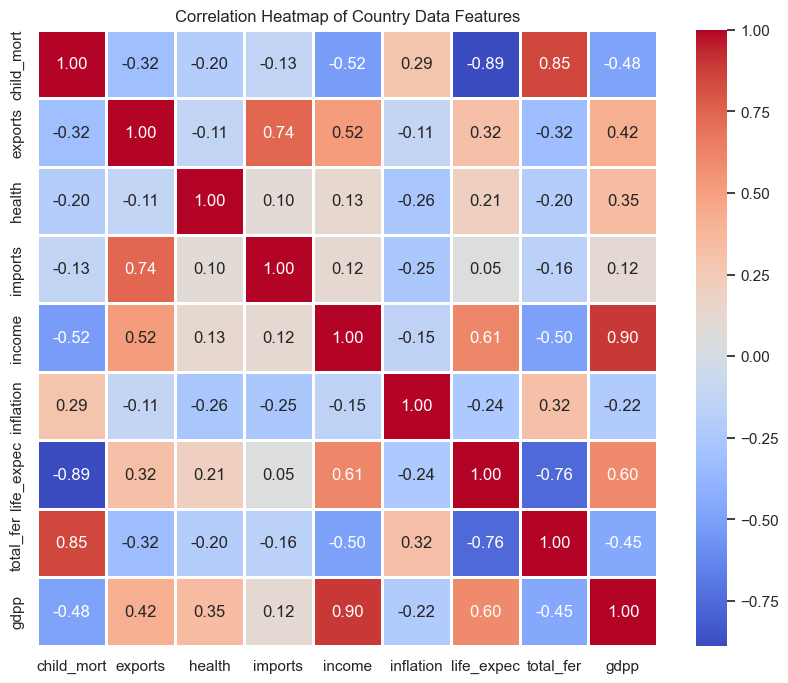

In [45]:
corr = updated_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=1
)
plt.title("Correlation Heatmap of Country Data Features")

### Key Observations

***Strong Positive Correlations (Above 0.75)***

**income vs gdpp (0.90)**: Nearly perfect correlation. That is, wealthier nations have higher GDP per capita, as expected.

**child_mort vs total_fer (0.85)**: Countries with high child mortality rates also have high fertility rates, indicating less developed healthcare and education systems.

**exports vs imports (0.74)**: Trade partners tend to have balanced import/export relationships.

***Strong Negative Correlations (Below -0.70)***

**child_mort vs life_expec (-0.89)**: Inverse relationship means, high child mortality does not have an impact on life expectancy.

**income vs child_mort (-0.52)**: Higher income correlates with lower child mortality rates.

**life_expec vs total_fer (-0.76)**: Countries with longer life expectancy have lower fertility rates (development indicator).

In [46]:
# # Specifying the features we want to plot in the pair plot 
# features = ['child_mort', 'exports', 'imports', 'income', 'inflation', 
#             'life_expec', 'total_fer', 'gdpp']

# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# axes = axes.flatten()

# for idx, feature in enumerate(features):
#     sns.regplot(data=df, x=feature, y='csMPa', ax=axes[idx], 
#                 scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
#     axes[idx].set_title(f'{feature} vs Concrete Strength')
#     axes[idx].set_xlabel(feature)
#     axes[idx].set_ylabel('Strength (MPa)')

# plt.tight_layout()
# plt.show()

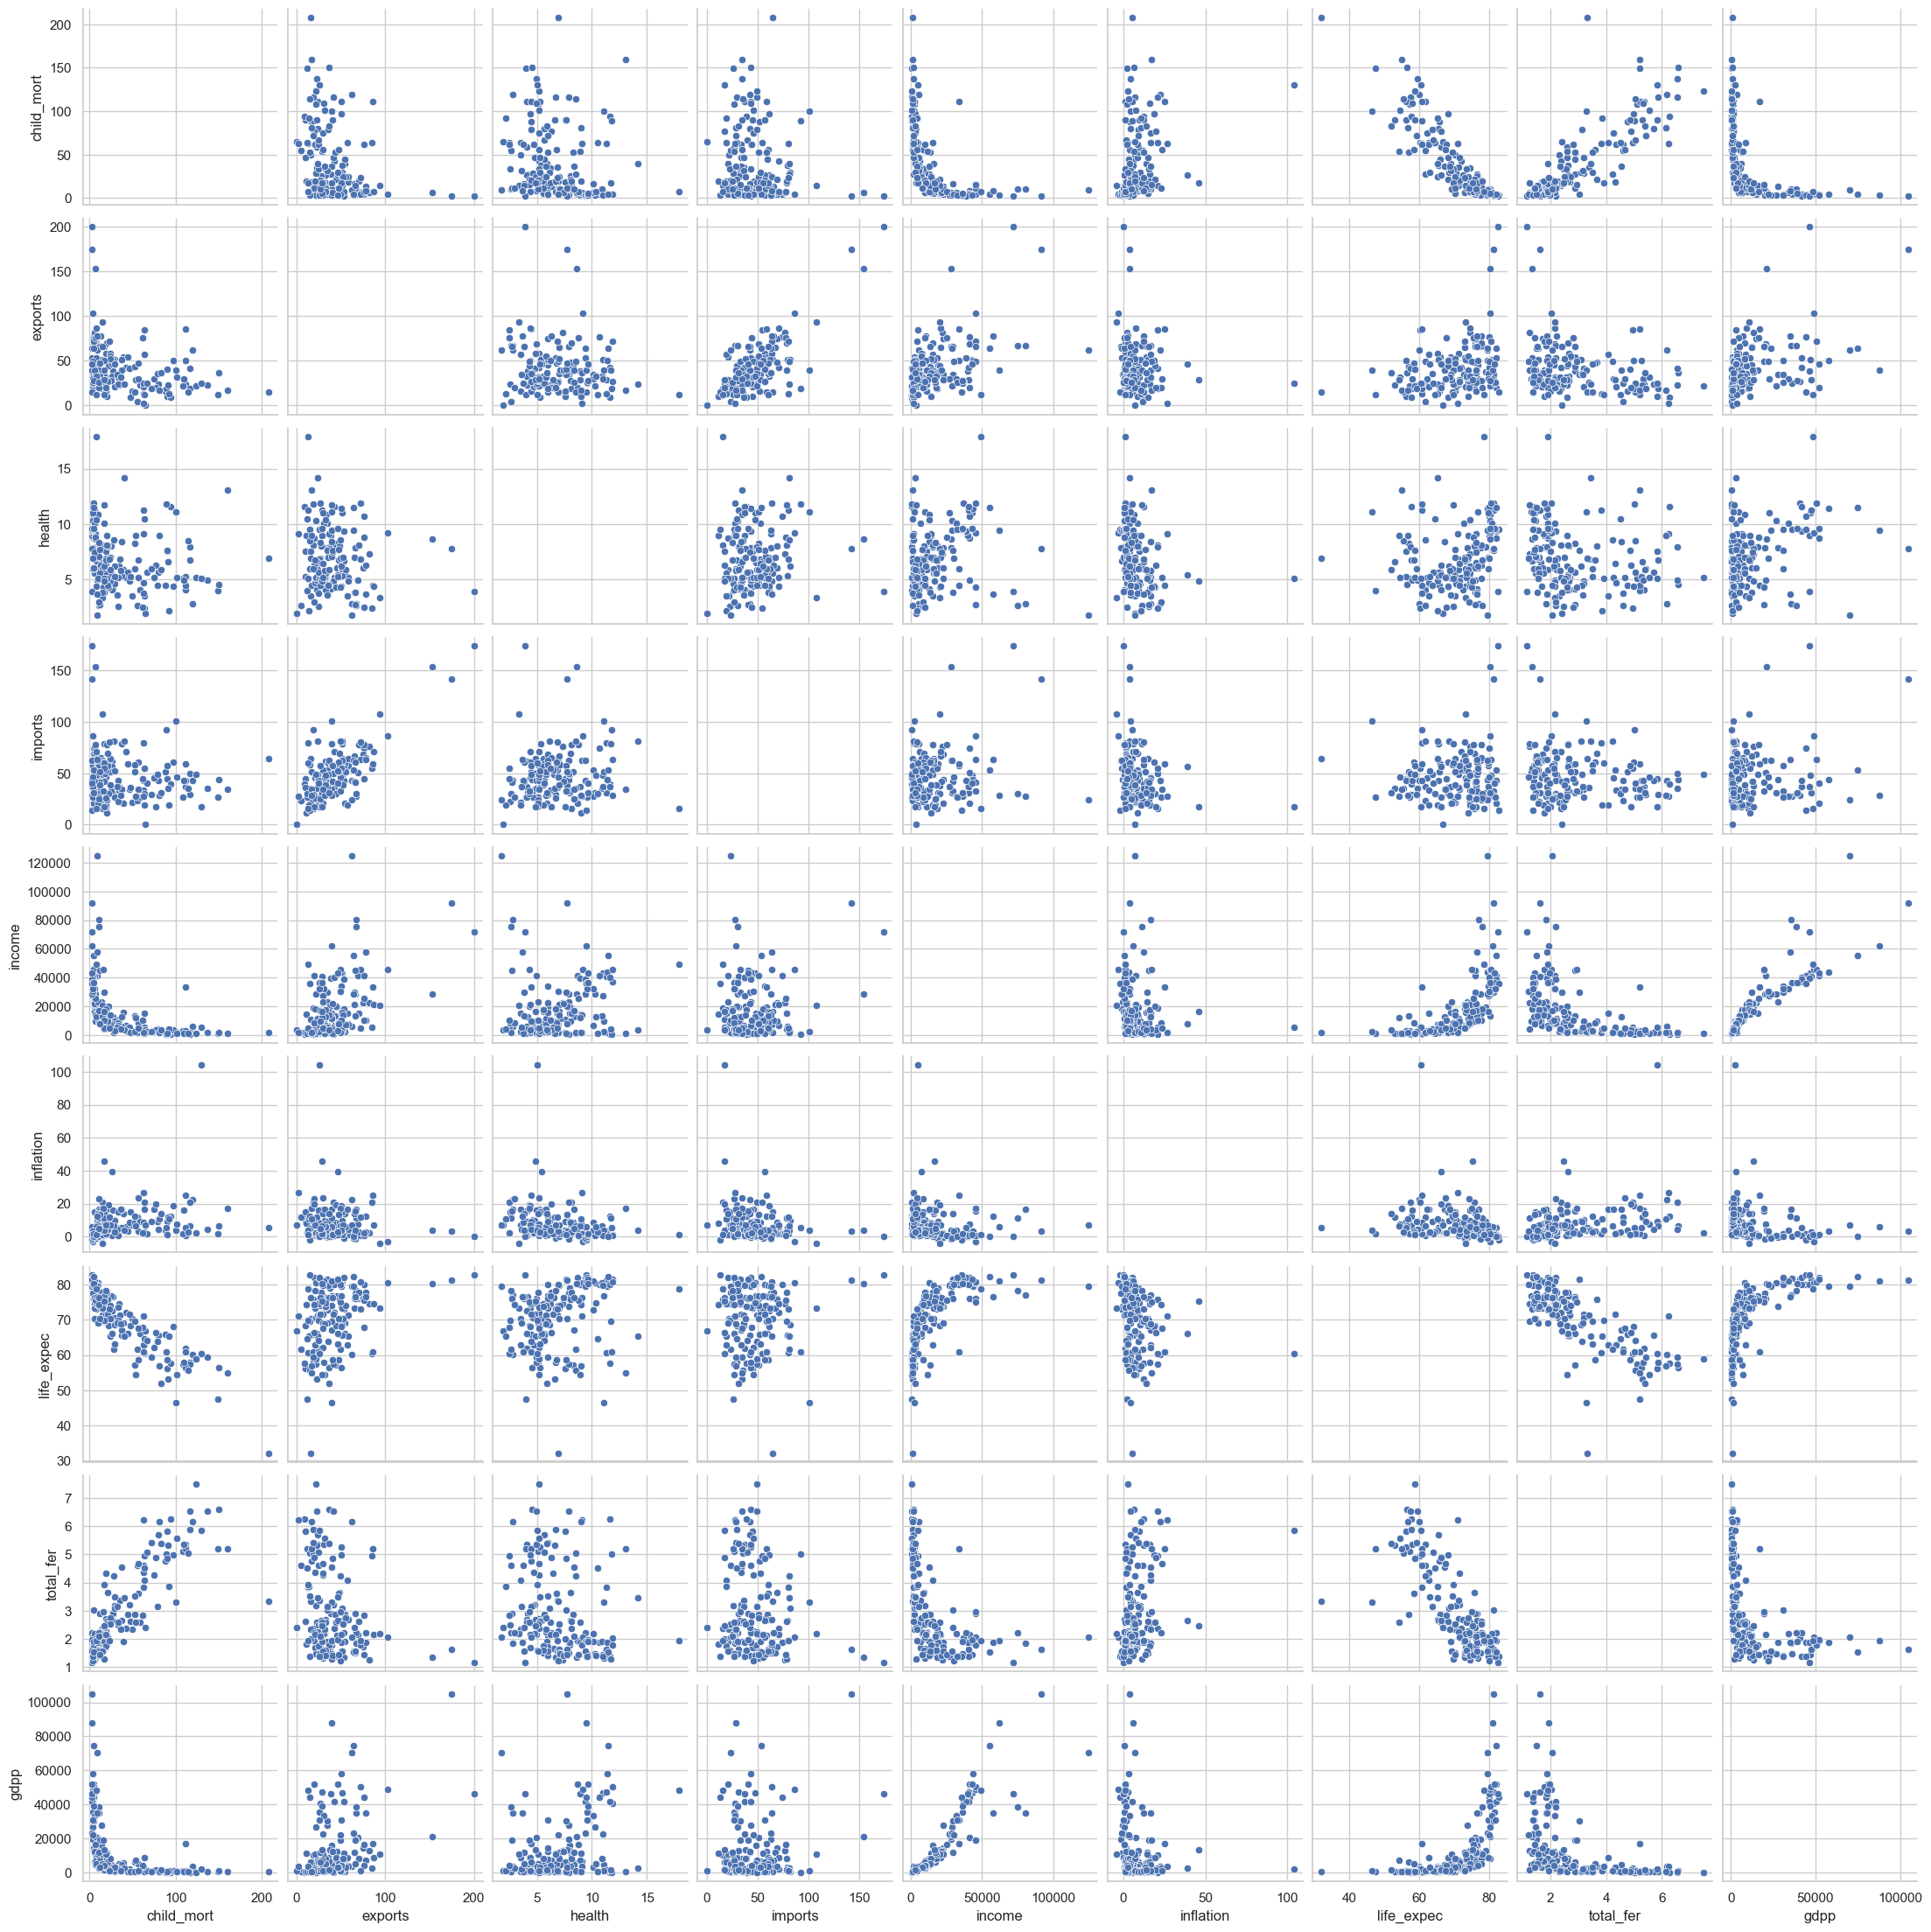

In [47]:
sns.pairplot(updated_df, diag_kind='scatterplot')
plt.show()

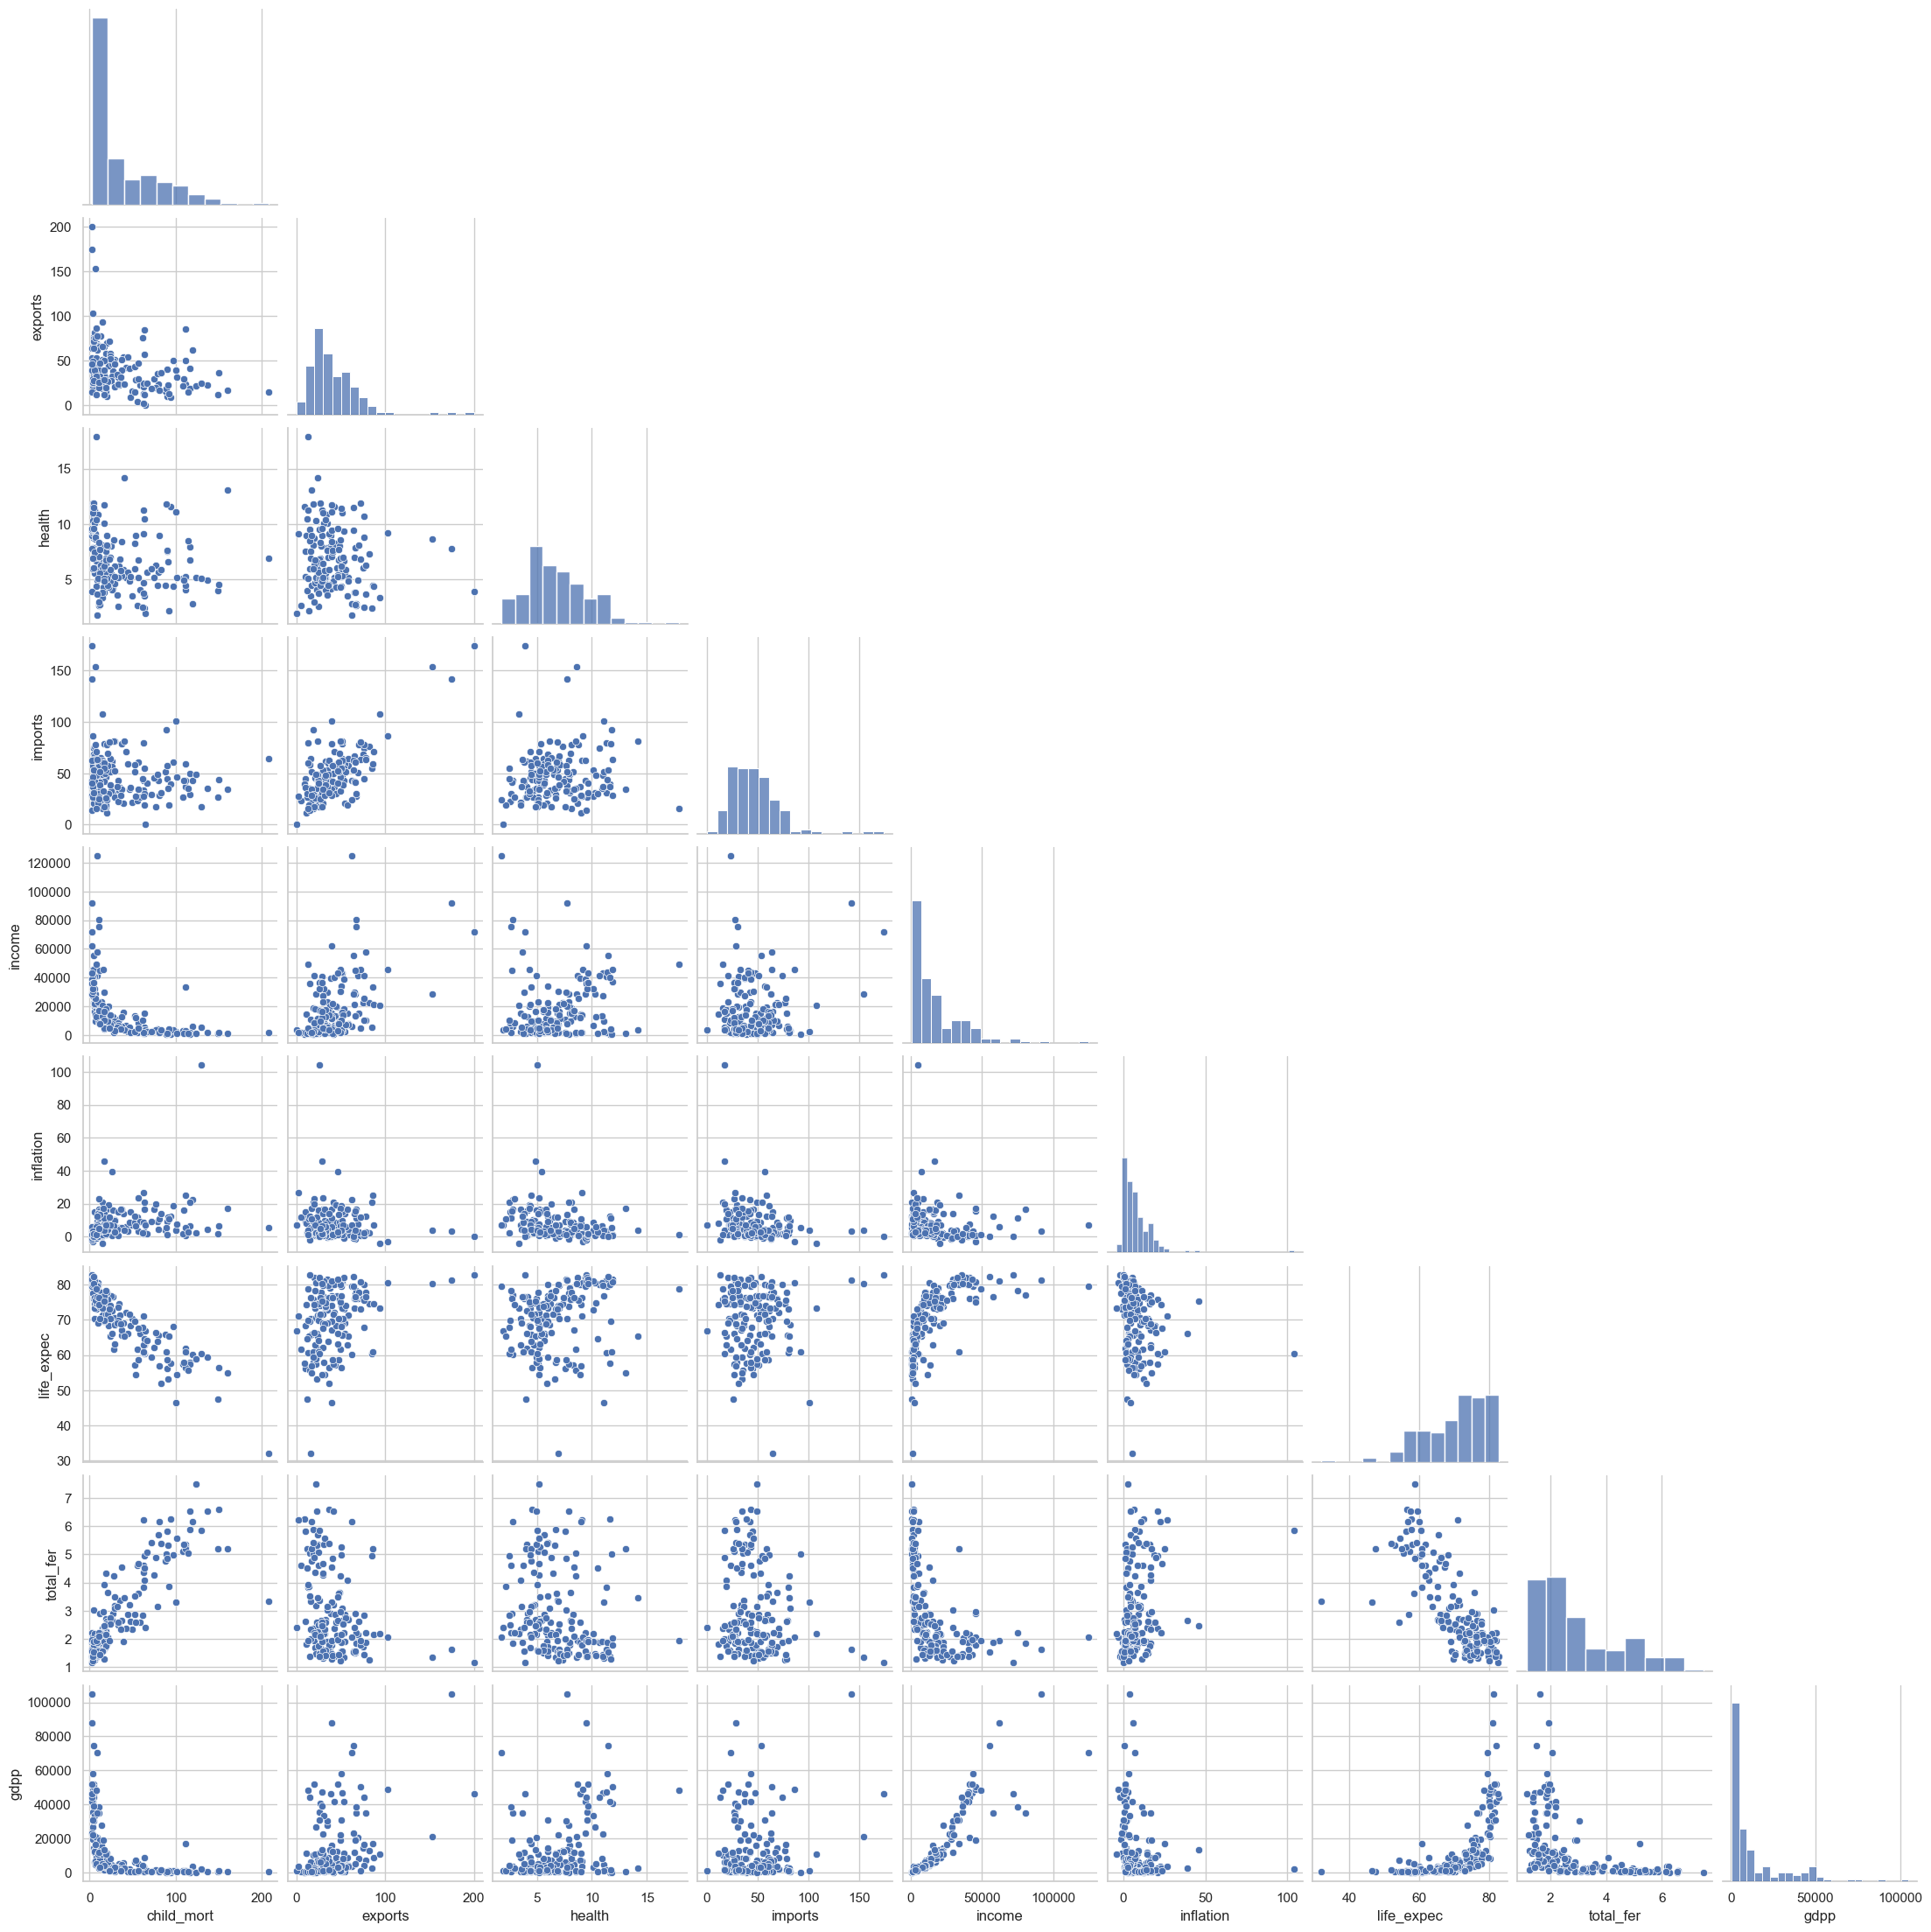

In [48]:
sns.set(style='whitegrid')
sns.pairplot(updated_df, diag_kind='hist', corner=True)
plt.show()



### Key Relationships
- **Positive Correlations**: income and life_expec, gdpp and income
- **Negative Correlations**: income and child_mort, total_fer and income, life_expec and child_mort
- **Clustering Benefit**: These correlations naturally group countries by development level

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(updated_df)

# Convert back to DataFrame for convenience
df_scaled = pd.DataFrame(scaled_data, columns=updated_df.columns)

df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [50]:
df_scaled.dtypes

child_mort    float64
exports       float64
health        float64
imports       float64
income        float64
inflation     float64
life_expec    float64
total_fer     float64
gdpp          float64
dtype: object

In [51]:
df_scaled.isna().sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


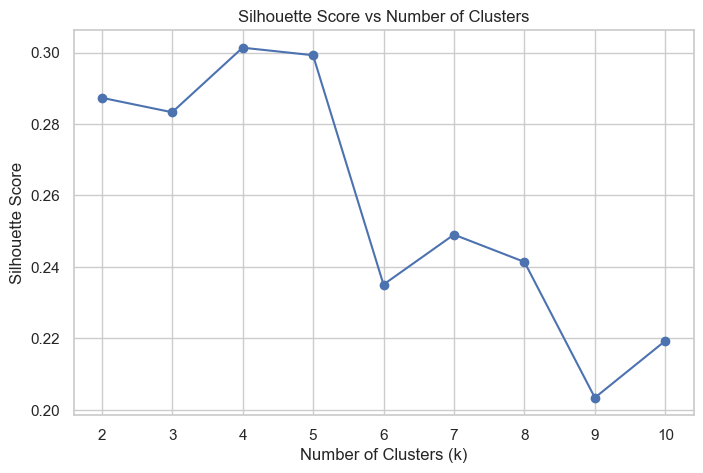

[0.28735668921406704,
 0.28329575683463126,
 0.301375962376881,
 0.2992594995920442,
 0.23506989275162896,
 0.24905003461730515,
 0.2414024552159115,
 0.2034069293261364,
 0.21931388763003506]

In [53]:
sil_scores = []
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()

sil_scores


Choosing the Optimal Number of Clusters
The silhouette scores for k = 2–10 show a clear maximum at k = 4, with a score of approximately 0.301. This indicates that four clusters provide the best balance between compactness and separation of clusters.
Although k = 5 also performs well, the improvement over k = 4 is negligible, and scores decline sharply for k ≥ 6, suggesting that additional clusters fragment the data without adding meaningful structure.
From a domain perspective, socioeconomic indicators for countries often fall into four broad groups (high‑income, upper‑middle‑income, lower‑middle‑income, and low‑income). The statistical result aligns with this real‑world interpretation, reinforcing the choice of k = 4 as the most appropriate model.
Therefore, the best model selected is the KMeans model with 4 clusters.


### 3

In [54]:
best_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
best_kmeans.fit(df_scaled)

KMeans(n_clusters=3, random_state=42)

In [55]:
df_scaled['cluster'] = best_kmeans.labels_

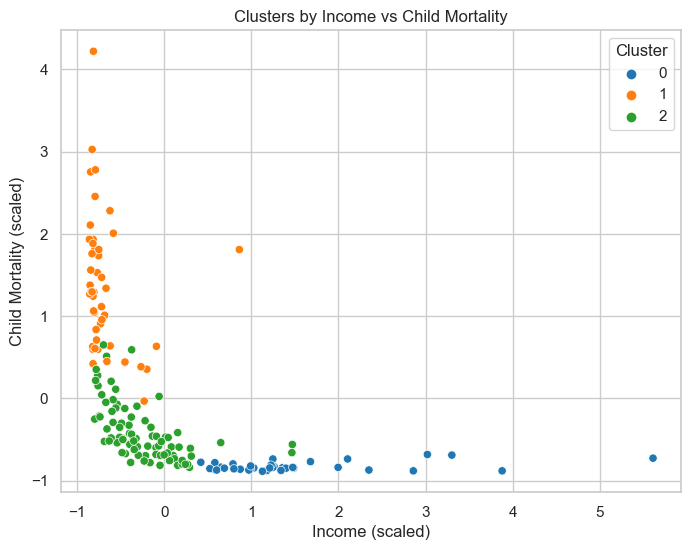

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_scaled.join(country_df),
    x="income",
    y="child_mort",
    hue="cluster",
    palette="tab10"
)
plt.title("Clusters by Income vs Child Mortality")
plt.xlabel("Income (scaled)")
plt.ylabel("Child Mortality (scaled)")
plt.legend(title="Cluster")
plt.show()

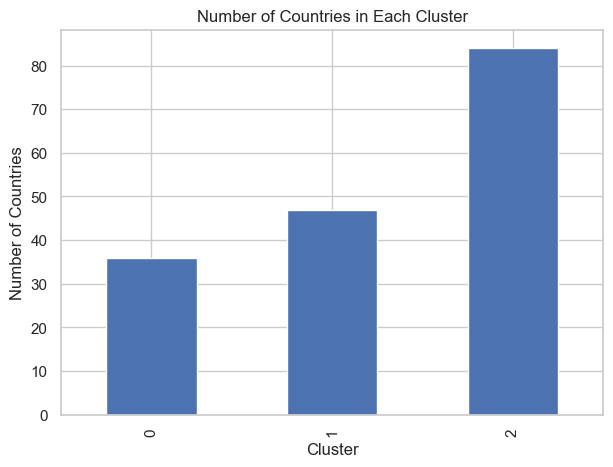

In [57]:
plt.figure(figsize=(7,5))
df_scaled['cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")
plt.title("Number of Countries in Each Cluster")
plt.show()

In [58]:
clustered_countries = country_df.copy()
clustered_countries['cluster'] = df_scaled['cluster']

for c in sorted(clustered_countries['cluster'].unique()):
    print(f"\nCluster {c}:")
    countries_in_cluster = clustered_countries[clustered_countries['cluster'] == c]['country'].tolist()
    print(countries_in_cluster)


Cluster 0:
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1:
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', '

In [59]:
cluster_summary = df_scaled.groupby('cluster').mean()
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,-0.827449,0.645080,0.727411,0.190639,1.484243,-0.484921,1.079579,-0.791877,1.615995
1,1.360218,-0.437533,-0.155984,-0.189204,-0.686894,0.402111,-1.282180,1.364944,-0.604242
2,-0.406453,-0.031653,-0.224471,0.024162,-0.251770,-0.017167,0.254734,-0.424343,-0.354481


In [60]:
aid_priority = [2, 1, 3, 0]  # from most need to least
aid_priority

[2, 1, 3, 0]

Explanation (Markdown-style):
Using the cluster averages, we rank clusters by need:
- The cluster with lowest income, highest child mortality, and lowest life expectancy is ranked as needing the most aid.
- Clusters with moderate income and improving health outcomes are ranked as medium priority.
- The cluster with high income, low child mortality, and high life expectancy is ranked as needing the least aid.
This ranking matches real‑world patterns: low‑income, high‑mortality countries face the greatest development challenges and should be prioritized.


In [61]:
total_aid = 100_000_000  # total funds

# Example: map cluster → need level (from Step 4)
# Replace with your actual ranking
most_need, second_need, third_need, least_need = aid_priority

allocation_pct = {
    most_need: 0.60,     # 60% of funds
    second_need: 0.25,   # 25%
    third_need: 0.10,    # 10%
    least_need: 0.05     # 5%
}

cluster_aid = {c: total_aid * pct for c, pct in allocation_pct.items()}
cluster_aid

{2: 60000000.0, 1: 25000000.0, 3: 10000000.0, 0: 5000000.0}

In [62]:
aid_per_country = []

for cluster_id, amount in cluster_aid.items():
    countries_in_cluster = clustered_countries[clustered_countries['cluster'] == cluster_id]['country']
    n = len(countries_in_cluster)
    per_country = amount / n if n > 0 else 0
    
    for country in countries_in_cluster:
        aid_per_country.append({
            "country": country,
            "cluster": cluster_id,
            "aid_amount": per_country
        })

aid_df = pd.DataFrame(aid_per_country)
aid_df.head()

,country,cluster,aid_amount
0,Albania,2,714285.714286
1,Algeria,2,714285.714286
2,Antigua and Barbuda,2,714285.714286
3,Argentina,2,714285.714286
4,Armenia,2,714285.714286


Explanation 
We allocate a fixed total aid budget across clusters based on their relative need:
- The highest‑need cluster receives the largest share of funds (e.g., 60%), reflecting severe poverty and poor health outcomes.
- Medium‑need clusters receive smaller but still substantial shares (e.g., 25% and 10%), supporting continued development and resilience.
- The least‑need cluster receives minimal or no aid, as these countries already have strong economic and health indicators.
Within each cluster, funds are divided equally among countries (a simple, transparent rule). In a more advanced analysis, we could weight allocations by population size or the severity of specific indicators (e.g., child mortality).
This strategy ensures that aid is targeted toward countries with the greatest need while still supporting those in transition, and it aligns with real‑world development priorities.


In [63]:
pwd

'c:\\Users\\hawla\\OneDrive\\Documents\\RRC\\COMP-3705-Unsupervised Machine Learning\\Unsupervised_Machine_Learning_Assignment'

In [64]:
!git init

Reinitialized existing Git repository in C:/Users/hawla/OneDrive/Documents/RRC/COMP-3705-Unsupervised Machine Learning/Unsupervised_Machine_Learning_Assignment/.git/


In [65]:
!git add

Nothing specified, nothing added.
hint: Maybe you wanted to say 'git add .'?
hint: Disable this message with "git config advice.addEmptyPathspec false"
